# CineMatch-AI — EDA (train set)

Exploratory analysis on `data/processed/train.parquet` — the oldest 70% of ratings used for model fitting.

Paths resolve automatically whether the kernel cwd is the repo root or `Notebooks/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
TRAIN_PATH = DATA_DIR / "processed" / "train.parquet"

if not TRAIN_PATH.exists():
    raise FileNotFoundError(
        f"{TRAIN_PATH} not found. Run Notebooks/data_prep.ipynb first."
    )

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

c:\Users\ahmed\Anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load lean columns for full-dataset stats (avoids loading poster_url, cast, etc.)
EDA_COLS = ["userId", "movieId", "rating", "timestamp", "genres", "release_year"]

print(f"Loading {TRAIN_PATH.name} ({', '.join(EDA_COLS)})...")
train = pd.read_parquet(TRAIN_PATH, columns=EDA_COLS)
print(train.shape)
train.head()

Loading train.parquet (userId, movieId, rating, timestamp, genres, release_year)...
(22373890, 6)


,userId,movieId,rating,timestamp,genres,release_year
0,1,17,4.0,944249077,Drama|Romance,1995.0
1,1,25,1.0,944250228,Drama|Romance,1995.0
2,1,29,2.0,943230976,Adventure|Drama|Fantasy|Mystery|Sci-Fi,1995.0
3,1,30,5.0,944249077,Crime|Drama,1995.0
4,1,32,5.0,943228858,Mystery|Sci-Fi|Thriller,1995.0


In [3]:
print("Dtypes:")
print(train.dtypes)
print("\nMissing values:")
print(train.isna().sum())
train.describe()

Dtypes:
userId                   int32
movieId                  int32
rating                 float32
timestamp                int64
genres          string[python]
release_year           float64
dtype: object

Missing values:
userId          0
movieId         0
rating          0
timestamp       0
genres          0
release_year    5
dtype: int64


,userId,movieId,rating,timestamp,release_year
count,2.237389e+07,2.237389e+07,2.237389e+07,2.237389e+07,2.237388e+07
mean,1.002118e+05,1.330477e+04,3.528588e+00,1.146714e+09,1.992673e+03
std,5.798136e+04,2.711945e+04,1.057574e+00,1.928492e+08,1.447793e+01
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08,1.874000e+03
25%,4.989500e+04,1.023000e+03,3.000000e+00,9.769987e+08,1.988000e+03
50%,1.002140e+05,2.454000e+03,3.500000e+00,1.126539e+09,1.995000e+03
75%,1.504770e+05,5.816000e+03,4.000000e+00,1.300870e+09,2.001000e+03
max,2.009480e+05,1.650970e+05,5.000000e+00,1.476365e+09,2.022000e+03


rating
0.5     311132
1.0     732764
1.5     331734
2.0    1545436
2.5    1047726
3.0    4619767
3.5    2613645
4.0    6105843
4.5    1815013
5.0    3250830
Name: count, dtype: int64


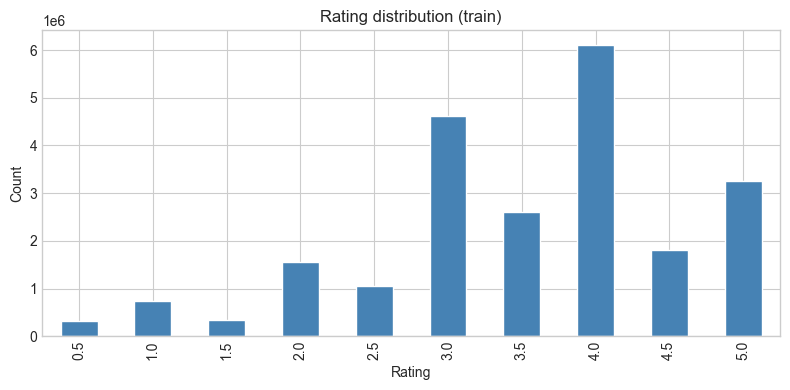

In [4]:
rating_counts = train["rating"].value_counts().sort_index()
print(rating_counts)

ax = rating_counts.plot(kind="bar", figsize=(8, 4), color="steelblue", edgecolor="white")
ax.set_title("Rating distribution (train)")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
n_users = train["userId"].nunique()
n_movies = train["movieId"].nunique()
n_ratings = len(train)

print(f"Users:   {n_users:,}")
print(f"Movies:  {n_movies:,}")
print(f"Ratings: {n_ratings:,}")
print(f"Sparsity: {100 * (1 - n_ratings / (n_users * n_movies)):.4f}% empty cells")

ratings_per_user = train.groupby("userId").size()
ratings_per_movie = train.groupby("movieId").size()

print("\nRatings per user:")
print(ratings_per_user.describe())
print("\nRatings per movie:")
print(ratings_per_movie.describe())

Users:   154,612
Movies:  36,010
Ratings: 22,373,890
Sparsity: 99.5981% empty cells

Ratings per user:
count    154612.000000
mean        144.709919
std         234.535950
min           1.000000
25%          35.000000
50%          68.000000
75%         154.000000
max       12672.000000
dtype: float64

Ratings per movie:
count    36010.000000
mean       621.324354
std       2940.016020
min          1.000000
25%          2.000000
50%          9.000000
75%        103.000000
max      76000.000000
dtype: float64


Date range: 1995-01-09 11:46:44 → 2016-10-13 13:27:36


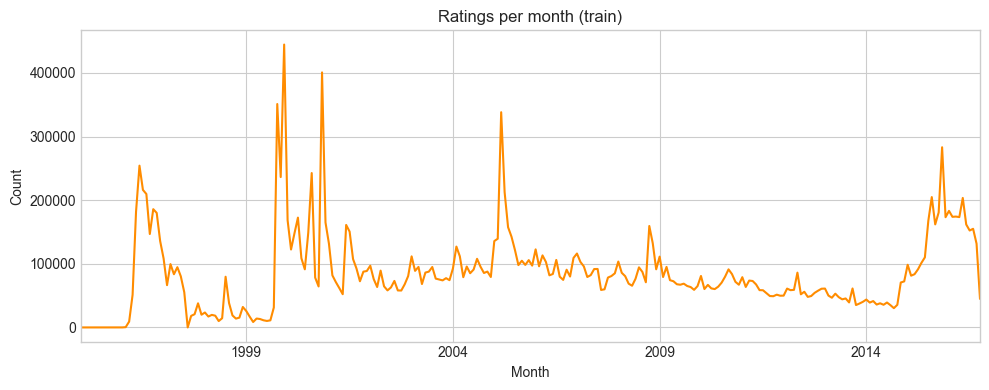

In [6]:
train["rating_date"] = pd.to_datetime(train["timestamp"], unit="s")

print(f"Date range: {train['rating_date'].min()} → {train['rating_date'].max()}")

monthly = train.set_index("rating_date").resample("ME")["rating"].count()
ax = monthly.plot(figsize=(10, 4), color="darkorange")
ax.set_title("Ratings per month (train)")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

genres
Drama        9912437
Comedy       8191695
Action       6483467
Thriller     6030981
Adventure    5060835
Romance      4201613
Crime        3754292
Sci-Fi       3668857
Fantasy      2436242
Children     1886772
Mystery      1774755
Horror       1653103
Animation    1338638
War          1164374
Musical       919568
Name: count, dtype: int64


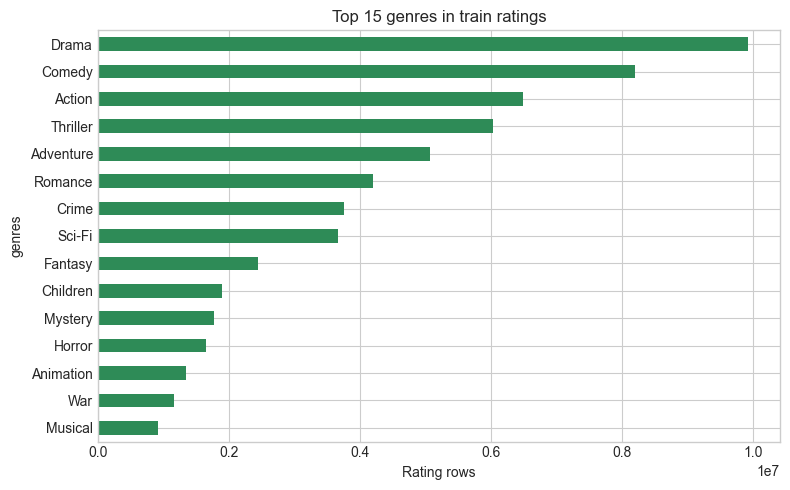

In [7]:
# One movie can have multiple genres — split on |
genre_lists = train["genres"].str.split("|")
all_genres = genre_lists.explode()
all_genres = all_genres[all_genres != "(no genres listed)"]

top_genres = all_genres.value_counts().head(15)
print(top_genres)

ax = top_genres.sort_values().plot(kind="barh", figsize=(8, 5), color="seagreen")
ax.set_title("Top 15 genres in train ratings")
ax.set_xlabel("Rating rows")
plt.tight_layout()
plt.show()

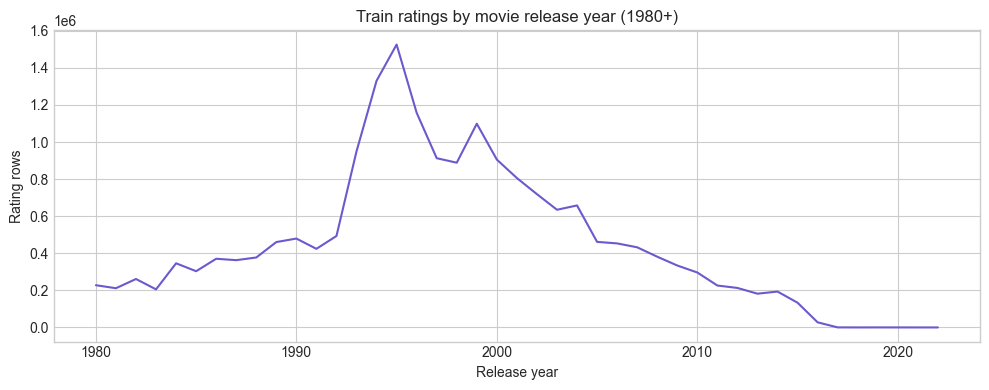

In [8]:
year_counts = train["release_year"].value_counts().sort_index()
recent = year_counts.loc[year_counts.index >= 1980]

ax = recent.plot(figsize=(10, 4), color="slateblue")
ax.set_title("Train ratings by movie release year (1980+)")
ax.set_xlabel("Release year")
ax.set_ylabel("Rating rows")
plt.tight_layout()
plt.show()

In [9]:
# Peek at full rows without loading the entire file
pf = pq.ParquetFile(TRAIN_PATH)
preview = next(pf.iter_batches(batch_size=5)).to_pandas()
preview

,userId,movieId,rating,timestamp,title,genres,tmdbId,director,cast,release_year,poster_url
0,1,17,4.0,944249077,Sense and Sensibility (1995),Drama|Romance,4584,Ang Lee,"Emma Thompson, Kate Winslet, Alan Rickman, Hug...",1995.0,https://image.tmdb.org/t/p/w500/cBK2yL3HqhFvIV...
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance,451,Mike Figgis,"Nicolas Cage, Elisabeth Shue, Julian Sands, Ri...",1995.0,https://image.tmdb.org/t/p/w500/wTrFpGe3U65kXT...
2,1,29,2.0,943230976,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,902,Marc Caro,"Ron Perlman, Dominique Pinon, Judith Vittet, D...",1995.0,https://image.tmdb.org/t/p/w500/whwT3Q9JxbAYzE...
3,1,30,5.0,944249077,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,37557,Zhang Yimou,"Gong Li, Li Baotian, Sun Chun, Li Xuejian, Liu...",1995.0,https://image.tmdb.org/t/p/w500/tzG1UxUSfPACRE...
4,1,32,5.0,943228858,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,63,Terry Gilliam,"Bruce Willis, Madeleine Stowe, Brad Pitt, Chri...",1995.0,https://image.tmdb.org/t/p/w500/gt3iyguaCIw8Dp...
